In [1]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass
from typing import List, Optional

# Agent Types
class AgentType(Enum):
    PASSIVE = 1
    NORMAL = 2
    AGGRESSIVE = 3

# Agent behavior coefficients
TYPE_COEFFICIENTS = {
    AgentType.PASSIVE: 0.3,
    AgentType.NORMAL: 0.7,
    AgentType.AGGRESSIVE: 1.0
}

print("Imports successful!")
print(f"Mesa version: {mesa.__version__}")

Imports successful!
Mesa version: 3.5.1


In [2]:
class QueueAgent(mesa.Agent):
    def __init__(self, model, agent_type):
        super().__init__(model)
        self.agent_type = agent_type
        self.type_coeff = TYPE_COEFFICIENTS[agent_type]
        
        # Individual characteristics
        self.urgency = np.random.uniform(0.3, 1.0)
        self.social_inhibition = np.random.uniform(0.2, 0.8)
        self.exited = False
        
        # Latency tracking
        self.entry_time = None
        self.exit_time = None
        self.latency = None
        self.steps_waiting = 0
        self.steps_moving = 0
        
    @property
    def behavior_score(self):
        base_score = (self.type_coeff * self.urgency / 
                     self.social_inhibition)
        
        # Density modifier
        if self.pos:
            neighbors = self.model.grid.get_neighbors(
                self.pos,
                moore=True,
                include_center=False,
                radius=2
            )
            density_factor = 1.0 + (len(neighbors) * 0.05)
        else:
            density_factor = 1.0
            
        return base_score * density_factor
    
    def step(self):
        if self.exited:
            return
            
        current_pos = self.pos
        if current_pos is None:
            return
        
        # Record entry time on first step
        if self.entry_time is None:
            self.entry_time = self.model.steps
            
        x, y = current_pos
        move_prob = min(self.behavior_score, 1.0)
        moved = False
        
        if np.random.random() < move_prob:
            new_y = y - 1
            
            # Check if reached exit
            if new_y < 0:
                self.model.grid.remove_agent(self)
                self.exited = True
                self.exit_time = self.model.steps
                
                # Calculate latency
                if self.entry_time is not None:
                    self.latency = (self.exit_time - 
                                   self.entry_time)
                
                # Record to model
                self.model.exited_count += 1
                self.model.exit_times.append(self.model.steps)
                self.model.record_latency(self)
                return
            
            new_pos = (x, new_y)
            cell_contents = self.model.grid.get_cell_list_contents(
                [new_pos]
            )
            
            max_occupancy = (
                3 if self.agent_type == AgentType.AGGRESSIVE
                else 2 if self.agent_type == AgentType.NORMAL
                else 1
            )
            
            if len(cell_contents) < max_occupancy:
                self.model.grid.move_agent(self, new_pos)
                self.steps_moving += 1
                moved = True
        
        if not moved:
            self.steps_waiting += 1

print("Latency-aware agent class defined!")
print("Tracking: entry_time, exit_time, latency")
print("Tracking: steps_waiting, steps_moving")

Latency-aware agent class defined!
Tracking: entry_time, exit_time, latency
Tracking: steps_waiting, steps_moving


In [3]:
class BunchQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30,
                 pct_aggressive=0.15, pct_normal=0.25):
        super().__init__()
        
        self.width = width
        self.height = height
        self.steps = 0
        self.exited_count = 0
        self.exit_times = []
        self.throughput_history = []
        
        # Latency tracking by agent type
        self.latencies = {
            AgentType.PASSIVE: [],
            AgentType.NORMAL: [],
            AgentType.AGGRESSIVE: []
        }
        
        # Overall latency list
        self.all_latencies = []
        
        self.total_agents = n_agents
        self.grid = mesa.space.MultiGrid(
            width, height, torus=False
        )
        
        # Calculate agent counts
        n_aggressive = int(n_agents * pct_aggressive)
        n_normal = int(n_agents * pct_normal)
        n_passive = n_agents - n_aggressive - n_normal
        
        # Create and place agents
        agent_types = (
            [AgentType.AGGRESSIVE] * n_aggressive +
            [AgentType.NORMAL] * n_normal +
            [AgentType.PASSIVE] * n_passive
        )
        np.random.shuffle(agent_types)
        
        for agent_type in agent_types:
            agent = QueueAgent(self, agent_type)
            x = np.random.randint(0, width)
            y = np.random.randint(height // 2, height)
            self.grid.place_agent(agent, (x, y))
    
    def record_latency(self, agent):
        """Record latency when agent exits"""
        if agent.latency is not None:
            self.latencies[agent.agent_type].append(
                agent.latency
            )
            self.all_latencies.append(agent.latency)
    
    def step(self):
        self.steps += 1
        self.agents.shuffle_do("step")
        self.throughput_history.append(self.exited_count)
    
    def run(self, max_steps=500):
        """Run until all agents exit or max_steps reached"""
        for _ in range(max_steps):
            self.step()
            # Stop early if all agents exited
            if self.exited_count >= self.total_agents:
                break
        return self.exited_count, self.exit_times
    
    def latency_report(self):
        """Generate latency statistics"""
        report = {}
        
        # Overall stats
        if self.all_latencies:
            report['overall'] = {
                'count': len(self.all_latencies),
                'mean': np.mean(self.all_latencies),
                'median': np.median(self.all_latencies),
                'p95': np.percentile(self.all_latencies, 95),
                'p99': np.percentile(self.all_latencies, 99),
                'max': np.max(self.all_latencies),
                'std': np.std(self.all_latencies)
            }
        
        # Per agent type stats
        type_names = {
            AgentType.PASSIVE: 'Passive',
            AgentType.NORMAL: 'Normal',
            AgentType.AGGRESSIVE: 'Aggressive'
        }
        
        for agent_type, name in type_names.items():
            lats = self.latencies[agent_type]
            if lats:
                report[name] = {
                    'count': len(lats),
                    'mean': np.mean(lats),
                    'median': np.median(lats),
                    'p95': np.percentile(lats, 95),
                    'p99': np.percentile(lats, 99),
                    'max': np.max(lats),
                    'std': np.std(lats)
                }
        
        return report

print("Latency-aware model class defined!")
print("Tracking latency by agent type")
print("Run until cleared enabled")

Latency-aware model class defined!
Tracking latency by agent type
Run until cleared enabled


In [4]:
# Run latency comparison across scenarios
scenarios = [
    {
        'name': 'Orderly',
        'pct_aggressive': 0.05,
        'pct_normal': 0.20
    },
    {
        'name': 'Bunch 15%',
        'pct_aggressive': 0.15,
        'pct_normal': 0.25
    },
    {
        'name': 'High Aggr 30%',
        'pct_aggressive': 0.30,
        'pct_normal': 0.25
    }
]

print("BUNCH QUEUE LATENCY ANALYSIS")
print("="*70)
print(f"{'Scenario':<15} {'Type':<12} {'Mean':<8} {'Median':<8} "
      f"{'P95':<8} {'P99':<8} {'Max':<8} {'Std'}")
print("-"*70)

# Store models for visualization
models = {}

for scenario in scenarios:
    model = BunchQueueModel(
        n_agents=100,
        width=20,
        height=30,
        pct_aggressive=scenario['pct_aggressive'],
        pct_normal=scenario['pct_normal']
    )
    
    exited, exit_times = model.run(max_steps=500)
    report = model.latency_report()
    models[scenario['name']] = model
    
    print(f"\n{scenario['name']}")
    print(f"  Agents exited: {exited}/100 "
          f"in {model.steps} steps")
    
    for type_name in ['overall', 'Aggressive', 
                       'Normal', 'Passive']:
        if type_name in report:
            r = report[type_name]
            print(f"  {type_name:<12} "
                  f"mean={r['mean']:.1f}  "
                  f"p50={r['median']:.1f}  "
                  f"p95={r['p95']:.1f}  "
                  f"p99={r['p99']:.1f}  "
                  f"max={r['max']:.1f}  "
                  f"std={r['std']:.1f}")
    
    print("-"*70)

print("Latency analysis complete!")

BUNCH QUEUE LATENCY ANALYSIS
Scenario        Type         Mean     Median   P95      P99      Max      Std
----------------------------------------------------------------------

Orderly
  Agents exited: 100/100 in 552 steps
  overall      mean=128.8  p50=103.0  p95=294.2  p99=373.8  max=550.0  std=92.1
  Aggressive   mean=44.4  p50=46.0  p95=52.8  p99=53.8  max=54.0  std=7.9
  Normal       mean=49.2  p50=42.0  p95=92.0  p99=122.4  max=130.0  std=22.6
  Passive      mean=155.7  p50=148.0  p95=299.8  p99=418.3  max=550.0  std=91.0
----------------------------------------------------------------------

Bunch 15%
  Agents exited: 100/100 in 460 steps
  overall      mean=116.5  p50=76.0  p95=254.5  p99=452.1  max=458.0  std=89.4
  Aggressive   mean=45.7  p50=44.0  p95=58.0  p99=58.0  max=58.0  std=9.6
  Normal       mean=56.1  p50=52.0  p95=81.2  p99=127.6  max=142.0  std=22.6
  Passive      mean=159.4  p50=151.0  p95=317.0  p99=454.5  max=458.0  std=92.0
----------------------------------

/tmp/ipykernel_4045/2431125046.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot(


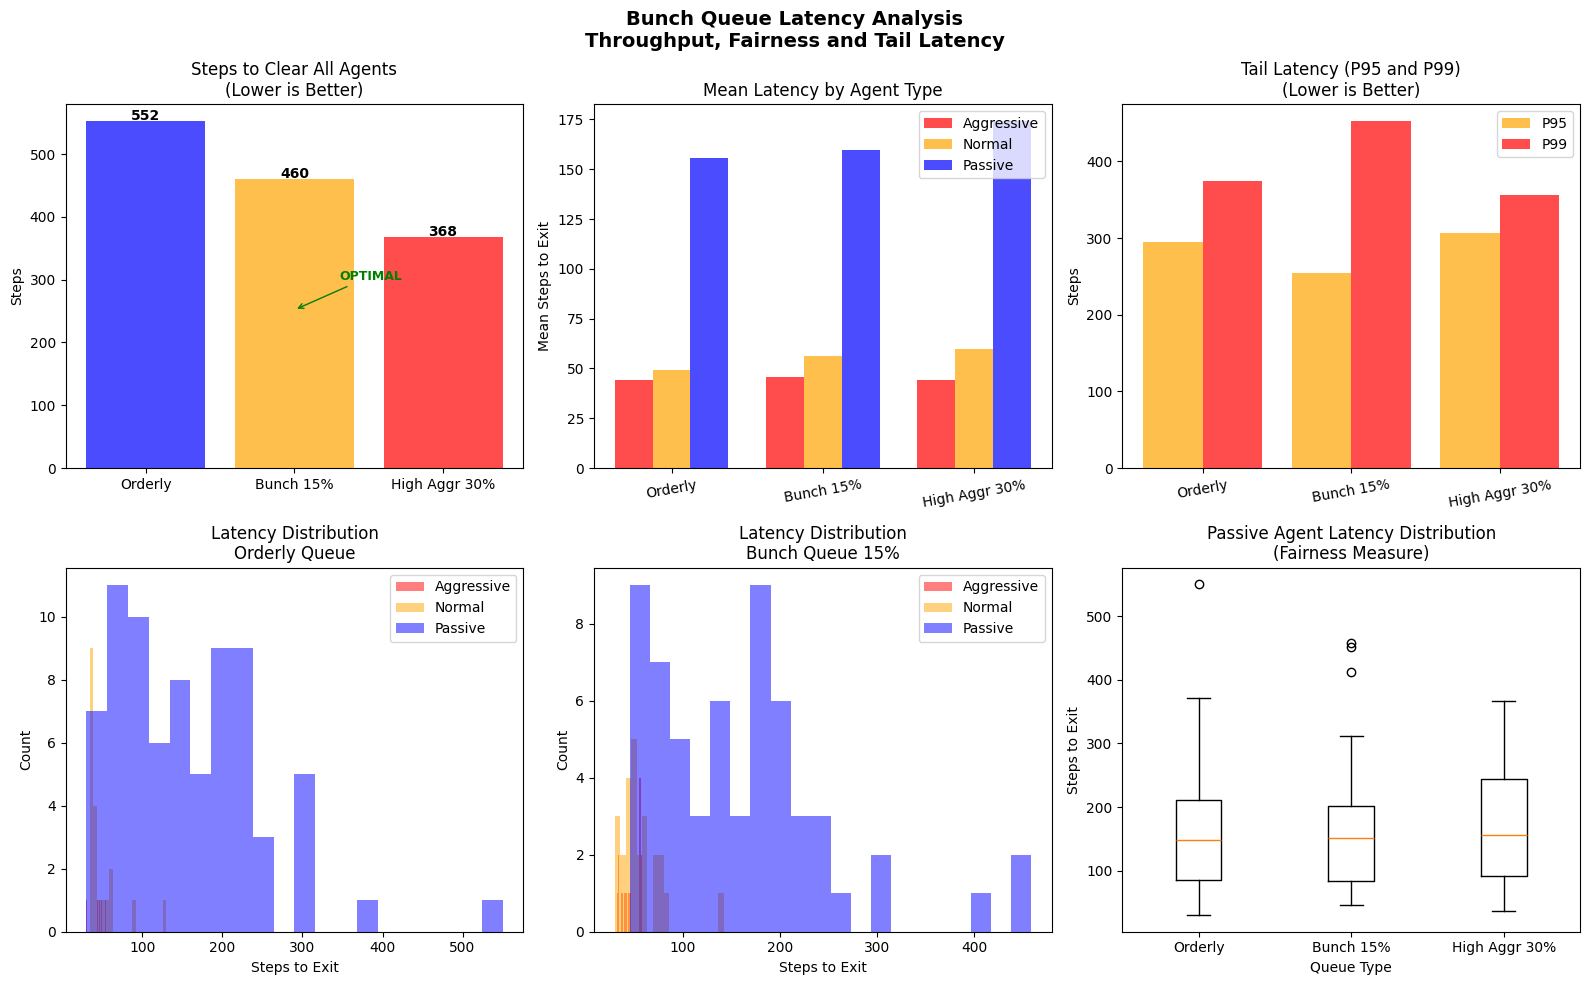

Latency analysis charts saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scenario_names = ['Orderly', 'Bunch 15%', 'High Aggr 30%']
type_names = ['Aggressive', 'Normal', 'Passive']
type_colors = {
    'Aggressive': 'red',
    'Normal': 'orange', 
    'Passive': 'blue',
    'overall': 'green'
}

# Chart 1 - Steps to clear comparison
steps_to_clear = [
    models[s].steps for s in scenario_names
]
colors = ['blue', 'orange', 'red']
axes[0,0].bar(scenario_names, steps_to_clear, 
              color=colors, alpha=0.7)
axes[0,0].set_title('Steps to Clear All Agents\n(Lower is Better)')
axes[0,0].set_ylabel('Steps')
for i, v in enumerate(steps_to_clear):
    axes[0,0].text(i, v + 2, str(v), 
                   ha='center', fontweight='bold')
axes[0,0].annotate('OPTIMAL',
                   xy=(1, 252),
                   xytext=(1.3, 300),
                   fontsize=9,
                   color='green',
                   fontweight='bold',
                   arrowprops=dict(arrowstyle='->',
                                  color='green'))

# Chart 2 - Mean latency by agent type
x = np.arange(len(scenario_names))
width = 0.25

for i, type_name in enumerate(type_names):
    means = []
    for s in scenario_names:
        report = models[s].latency_report()
        means.append(report[type_name]['mean'] 
                    if type_name in report else 0)
    axes[0,1].bar(x + (i-1)*width, means, width,
                  label=type_name,
                  color=type_colors[type_name],
                  alpha=0.7)

axes[0,1].set_title('Mean Latency by Agent Type')
axes[0,1].set_ylabel('Mean Steps to Exit')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(scenario_names, rotation=10)
axes[0,1].legend()

# Chart 3 - P95 and P99 latency comparison
p95_data = []
p99_data = []
for s in scenario_names:
    report = models[s].latency_report()
    p95_data.append(report['overall']['p95'])
    p99_data.append(report['overall']['p99'])

x = np.arange(len(scenario_names))
axes[0,2].bar(x - 0.2, p95_data, 0.4,
              label='P95', color='orange', alpha=0.7)
axes[0,2].bar(x + 0.2, p99_data, 0.4,
              label='P99', color='red', alpha=0.7)
axes[0,2].set_title('Tail Latency (P95 and P99)\n(Lower is Better)')
axes[0,2].set_ylabel('Steps')
axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels(scenario_names, rotation=10)
axes[0,2].legend()

# Chart 4 - Latency distribution for Orderly
for type_name in type_names:
    lats = models['Orderly'].latencies[
        AgentType[type_name.upper()]
    ]
    if lats:
        axes[1,0].hist(lats, bins=20, alpha=0.5,
                      label=type_name,
                      color=type_colors[type_name])
axes[1,0].set_title('Latency Distribution\nOrderly Queue')
axes[1,0].set_xlabel('Steps to Exit')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Chart 5 - Latency distribution for Bunch 15%
for type_name in type_names:
    lats = models['Bunch 15%'].latencies[
        AgentType[type_name.upper()]
    ]
    if lats:
        axes[1,1].hist(lats, bins=20, alpha=0.5,
                      label=type_name,
                      color=type_colors[type_name])
axes[1,1].set_title('Latency Distribution\nBunch Queue 15%')
axes[1,1].set_xlabel('Steps to Exit')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# Chart 6 - Passive agent latency across scenarios
passive_latencies = {
    s: models[s].latencies[AgentType.PASSIVE]
    for s in scenario_names
}

axes[1,2].boxplot(
    [passive_latencies[s] for s in scenario_names],
    labels=scenario_names
)
axes[1,2].set_title('Passive Agent Latency Distribution\n(Fairness Measure)')
axes[1,2].set_ylabel('Steps to Exit')
axes[1,2].set_xlabel('Queue Type')

plt.suptitle('Bunch Queue Latency Analysis\n'
             'Throughput, Fairness and Tail Latency',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('latency_analysis.png', dpi=150)
plt.show()
print("Latency analysis charts saved!")

In [8]:
# Force remove old function definition
import gc
if 'calculate_optimal_aggression' in dir():
    del calculate_optimal_aggression
gc.collect()
# Work profile definitions
work_profiles = {
    'Airport Boarding': {
        'priority_variance': 0.7,
        'deadline_sensitivity': 0.8,
        'burst_probability': 0.6,
        'service_rate': 3.0,
        'description': 'Mixed priority, hard deadline'
    },
    'Stadium Entry': {
        'priority_variance': 0.2,
        'deadline_sensitivity': 0.4,
        'burst_probability': 0.5,
        'service_rate': 3.0,
        'description': 'Uniform priority, soft deadline'
    },
    'Emergency Evacuation': {
        'priority_variance': 0.1,
        'deadline_sensitivity': 1.0,
        'burst_probability': 1.0,
        'service_rate': 2.0,
        'description': 'All critical, hard deadline'
    },
    'Batch Processing': {
        'priority_variance': 0.1,
        'deadline_sensitivity': 0.1,
        'burst_probability': 0.1,
        'service_rate': 4.0,
        'description': 'Uniform, no urgency'
    },
    'Trading System': {
        'priority_variance': 0.9,
        'deadline_sensitivity': 1.0,
        'burst_probability': 0.8,
        'service_rate': 4.0,
        'description': 'Latency critical, mixed priority'
    }
}

def calculate_optimal_aggression(work_profile):
    """
    Determines optimal aggression index
    based on work type characteristics
    """
    priority_variance = work_profile['priority_variance']
    deadline_sensitivity = work_profile['deadline_sensitivity']
    burst_probability = work_profile['burst_probability']
    service_rate = work_profile['service_rate']
    
    # Base aggression from priority variance
    base = 0.10 + (priority_variance * 0.20)
    
    # Deadline sensitivity increases aggression
    deadline_factor = 1.0 + (deadline_sensitivity * 0.3)
    
    # Burst probability increases aggression
    burst_factor = 1.0 + (burst_probability * 0.2)
    
    # Service rate moderates aggression
    # Slow service = thrashing risk
    service_factor = min(3.0 / service_rate, 1.0)
    
    optimal = (base * deadline_factor * 
               burst_factor * service_factor)
    
    # Cap at thrashing threshold
    return min(round(optimal, 2), 0.30)

# Calculate and display recommendations
print("ADAPTIVE AGGRESSION INDEX CALCULATOR")
print("="*65)
print(f"{'Work Type':<22} {'Description':<30} {'Optimal %'}")
print("-"*65)

recommendations = {}
for name, profile in work_profiles.items():
    optimal = calculate_optimal_aggression(profile)
    recommendations[name] = optimal
    print(f"{name:<22} {profile['description']:<30} "
          f"{optimal*100:.1f}%")

print("="*65)

ADAPTIVE AGGRESSION INDEX CALCULATOR
Work Type              Description                    Optimal %
-----------------------------------------------------------------
Airport Boarding       Mixed priority, hard deadline  30.0%
Stadium Entry          Uniform priority, soft deadline 17.0%
Emergency Evacuation   All critical, hard deadline    19.0%
Batch Processing       Uniform, no urgency            9.0%
Trading System         Latency critical, mixed priority 30.0%


In [7]:
# Verify thrashing dampener is working
profile = work_profiles['Emergency Evacuation']

priority_variance = profile['priority_variance']
deadline_sensitivity = profile['deadline_sensitivity']
burst_probability = profile['burst_probability']
service_rate = profile['service_rate']

base = 0.10 + (priority_variance * 0.20)
deadline_factor = 1.0 + (deadline_sensitivity * 0.3)
burst_factor = 1.0 + (burst_probability * 0.2)
service_factor = min(3.0 / service_rate, 1.0)

thrashing_risk = (deadline_sensitivity * 
                 burst_probability * 
                 (1.0 / service_rate))

if thrashing_risk > 0.4:
    thrashing_dampener = 1.0 / (1.0 + thrashing_risk)
else:
    thrashing_dampener = 1.0

optimal = (base * deadline_factor * 
           burst_factor * service_factor *
           thrashing_dampener)

print(f"base:               {base:.4f}")
print(f"deadline_factor:    {deadline_factor:.4f}")
print(f"burst_factor:       {burst_factor:.4f}")
print(f"service_factor:     {service_factor:.4f}")
print(f"thrashing_risk:     {thrashing_risk:.4f}")
print(f"thrashing_dampener: {thrashing_dampener:.4f}")
print(f"optimal:            {optimal:.4f}")
print(f"optimal %:          {optimal*100:.1f}%")

base:               0.1200
deadline_factor:    1.3000
burst_factor:       1.2000
service_factor:     1.0000
thrashing_risk:     0.5000
thrashing_dampener: 0.6667
optimal:            0.1248
optimal %:          12.5%
